# Inteligencia Computacional — Guía de trabajos prácticos 2


In [13]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path

from src.data_loader import cargar_patrones, armar_arquitectura
from src.graficos import (
    graficar_y_animar_regiones,
    graficar_comparacion,
    graficar_clasificacion,
    graficar_curvas_por_tasa,
)

DIRECTORIO_DATASET = Path("Dataset")
DIRECTORIO_GRAFICOS = Path("Graficos")


class PerceptronMulticapa:

    def __init__(self, capas, alpha=0.1, semilla=None):
        self.capas = capas
        self.alpha = alpha
        self.n = len(capas) - 1

        if semilla is not None:
            np.random.seed(semilla)

        self.pesos = []
        for i in range(self.n):
            self.pesos.append(np.random.uniform(-0.5, 0.5, (capas[i], capas[i + 1])))

        self.umbrales = []
        for i in range(self.n):
            self.umbrales.append(np.random.uniform(-0.5, 0.5, capas[i + 1]))

    def sigmoide(self, v):
        return 2 / (1 + np.exp(-v)) - 1

    def derivada_sigmoide(self, y):
        return 0.5 * (1 - y ** 2)

    # =========================================================================
    # PASO 1: ADELANTE (FORWARD PROPAGATION)
    # =========================================================================
    def propagar(self, entrada):
        y = [entrada.copy()]

        # Recorremos cada capa de conexiones
        for capa in range(self.n):
            entradas_i = y[capa]
            cantidad_neuronas_j = self.pesos[capa].shape[1]
            
            salidas_capa = np.zeros(cantidad_neuronas_j)
            
            # Calculamos la salida para CADA neurona 'j' de esta capa
            for j in range(cantidad_neuronas_j):
                v_j = 0.0
                
                # 1. Sumatoria: v_j = suma_i (w_ji * y_i)
                for i in range(len(entradas_i)):
                    v_j += self.pesos[capa][i, j] * entradas_i[i]
                
                # 2. Sumamos el umbral (bias)
                v_j += self.umbrales[capa][j]
                
                # 3. Aplicamos la función de activación: y_j = phi(v_j)
                salidas_capa[j] = self.sigmoide(v_j)
            
            y.append(salidas_capa)

        return y

    # =========================================================================
    # PASO 2: ATRÁS (BACKPROPAGATION)
    # =========================================================================
    def calcular_deltas(self, y, error):
        delta = [None] * self.n

        # A. CAPA DE SALIDA (la última capa, que compara con el valor deseado)
        delta[-1] = np.zeros(len(error))
        for j in range(len(error)):
            # Fórmula: delta_j = e_j * phi'(v_j)
            delta[-1][j] = error[j] * self.derivada_sigmoide(y[-1][j])

        # B. CAPAS OCULTAS (se calculan desde el final hacia el principio)
        for capa in range(self.n - 2, -1, -1):
            cantidad_neuronas_j = self.pesos[capa].shape[1]
            cantidad_neuronas_k = self.pesos[capa + 1].shape[1]
            
            delta_capa_actual = np.zeros(cantidad_neuronas_j)
            
            # Calculamos el delta para CADA neurona oculta 'j'
            for j in range(cantidad_neuronas_j):
                suma_deltas = 0.0
                
                # Sumatoria del error propagado desde la capa siguiente (k)
                # Fórmula: suma_k (delta_k * w_kj)
                for k in range(cantidad_neuronas_k):
                    w_kj = self.pesos[capa + 1][j, k]
                    suma_deltas += delta[capa + 1][k] * w_kj
                
                # Fórmula final: delta_j = [suma_k ...] * phi'(v_j)
                delta_capa_actual[j] = suma_deltas * self.derivada_sigmoide(y[capa + 1][j])
            
            delta[capa] = delta_capa_actual

        return delta

    # =========================================================================
    # PASO 3: AJUSTE (REGLA DEL DELTA)
    # =========================================================================
    def actualizar_pesos(self, y, delta):
        # Recorremos cada matriz de pesos de la red
        for capa in range(self.n):
            cantidad_entradas_i = self.pesos[capa].shape[0]
            cantidad_neuronas_j = self.pesos[capa].shape[1]

            # Actualizamos los pesos y umbrales de CADA neurona 'j'
            for j in range(cantidad_neuronas_j):
                
                # 1. Ajuste del umbral: delta_b_j = alpha * delta_j
                self.umbrales[capa][j] += self.alpha * delta[capa][j]
                
                # 2. Ajuste de los pesos: delta_w_ji = alpha * delta_j * y_i
                for i in range(cantidad_entradas_i):
                    ajuste = self.alpha * delta[capa][j] * y[capa][i]
                    self.pesos[capa][i, j] += ajuste

    # ---------------------------------------------------------------- el patron completo

    def entrenar_un_patron(self, entrada, deseada):
        y = self.propagar(entrada)              
        error = deseada - y[-1]                 
        delta = self.calcular_deltas(y, error)  
        self.actualizar_pesos(y, delta)         
        return error

    def clasificar(self, entradas):
        # En la clasificación por lotes devolvemos a np.dot por pura velocidad
        salidas = []
        for entrada in entradas:
            salidas.append(self.propagar(entrada)[-1])
        salidas = np.array(salidas)

        if salidas.shape[1] == 1:
            return np.where(salidas[:, 0] >= 0, 1.0, -1.0)
        return np.argmax(salidas, axis=1)

    @staticmethod
    def clase_deseada(deseadas):
        if deseadas.ndim == 1:
            return np.where(deseadas >= 0, 1.0, -1.0)
        return np.argmax(deseadas, axis=1)

    def probar(self, entradas, deseadas):
        aciertos = self.clasificar(entradas) == self.clase_deseada(deseadas)
        return 100 * aciertos.mean(), int((~aciertos).sum())

    def entrenar(self, entradas, deseadas, maximo_epocas=1000, tolerancia=0.0,
                 guardar_historial=False):
        
        errores_por_epoca = []
        error_cuadratico_por_epoca = []
        historial = []

        if deseadas.ndim == 1:
            deseadas_matriz = deseadas[:, None]
        else:
            deseadas_matriz = deseadas

        for epoca in range(maximo_epocas):
            suma_cuadratica = 0.0

            indices = np.random.permutation(len(entradas))

            for i in indices:
                error = self.entrenar_un_patron(entradas[i], deseadas_matriz[i])
                suma_cuadratica = suma_cuadratica + 0.5 * float(np.sum(error ** 2))

            _, cantidad_errores = self.probar(entradas, deseadas)
            errores_por_epoca.append(cantidad_errores)
            error_cuadratico_por_epoca.append(suma_cuadratica)

            if guardar_historial:
                historial.append(([w.copy() for w in self.pesos],
                                  [u.copy() for u in self.umbrales]))

            if cantidad_errores == 0 and suma_cuadratica / len(entradas) < tolerancia:
                break

        return errores_por_epoca, error_cuadratico_por_epoca, historial

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Ejercicio 1

> Implemente el algoritmo de retropropagación para un perceptrón multicapa de forma que
> se pueda elegir libremente la cantidad de capas de la red y de neuronas en cada capa.
> Pruébelo entrenando una red de estructura apropiada para resolver el problema XOR, con
> sus particiones de entrenamiento y prueba correspondientes (datos de la Guía de Trabajos
> Prácticos 1).

arquitectura: [2, 2, 1]
épocas usadas:  2 de 500
error cuadratico final:    17.9714
prueba:         100.00 %  
(0 errores de 200)


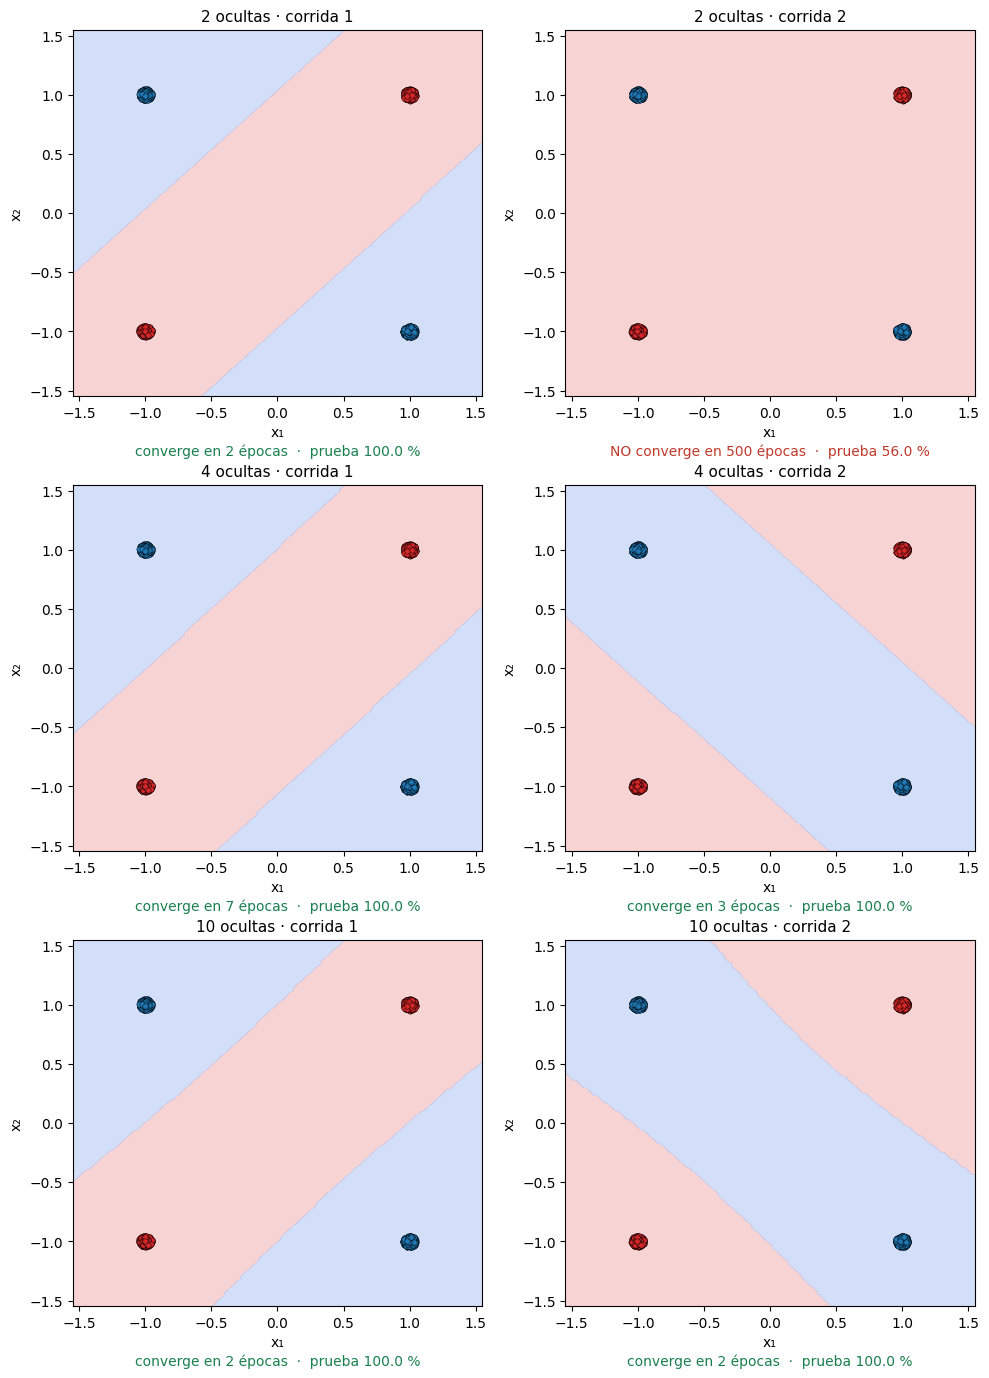

In [14]:
# 1. CARGAR LOS PATRONES ------------------------------------------------------
entradas_xor, deseadas_xor = cargar_patrones(DIRECTORIO_DATASET / "XOR_trn.csv")
entradas_xor_prueba, deseadas_xor_prueba = cargar_patrones(DIRECTORIO_DATASET / "XOR_tst.csv")


# 2. DEFINIR LA CONFIGURACION -------------------------------------------------
CANTIDAD_ENTRADAS = 2  
NEURONAS_OCULTAS  = [2]                     # una capa oculta de X neuronas
CANTIDAD_SALIDAS  = 1                       # dos clases: alcanza una salida ±1

TASA_APRENDIZAJE = 0.1     # cuanto se mueven los pesos en cada correccion
SEMILLA          = 42      # fija la red inicial: con la misma semilla, el mismo resultado
MAXIMO_EPOCAS    = 500     # cuantas pasadas completas como maximo
TOLERANCIA       = 0.1     # corta antes si no hay errores y el error medio baja de esto

arquitectura_xor = armar_arquitectura(CANTIDAD_ENTRADAS, NEURONAS_OCULTAS, CANTIDAD_SALIDAS)
print("arquitectura:", arquitectura_xor)


# 3. CREAR LA RED -------------------------------------------------------------
red_xor = PerceptronMulticapa(arquitectura_xor, TASA_APRENDIZAJE, SEMILLA)


# 4. ENTRENAR -----------------------------------------------------------------
errores_por_epoca_xor, error_cuadratico_por_epoca_xor, historial_xor = red_xor.entrenar(
    entradas_xor, deseadas_xor,
    maximo_epocas=MAXIMO_EPOCAS, tolerancia=TOLERANCIA, guardar_historial=True,
)


# 5. PROBAR -------------------------------------------------------------------
porcentaje_aciertos, cantidad_errores = red_xor.probar(entradas_xor_prueba, deseadas_xor_prueba)

print(f"épocas usadas:  {len(errores_por_epoca_xor)} de {MAXIMO_EPOCAS}")
print(f"error cuadratico final:    {error_cuadratico_por_epoca_xor[-1]:.4f}")
print(f"prueba:         {porcentaje_aciertos:.2f} %  ")
print(f"({cantidad_errores} errores de {len(deseadas_xor_prueba)})")


casos = []

for ocultas in ([2], [4,3], [10]):
    fila = []
    for corrida in (1, 2):
        red = PerceptronMulticapa(armar_arquitectura(CANTIDAD_ENTRADAS, ocultas, CANTIDAD_SALIDAS), TASA_APRENDIZAJE) # sin semilla: arranca distinto cada vez
        errores, _, _ = red.entrenar(entradas_xor, deseadas_xor, maximo_epocas=MAXIMO_EPOCAS, tolerancia=TOLERANCIA)
        convergio = errores[-1] == 0
        porcentaje_aciertos, _ = red.probar(entradas_xor_prueba, deseadas_xor_prueba)

        fila.append({
            "red": red,
            "titulo": f"{ocultas[0]} ocultas · corrida {corrida}",
            "pie": (f"{'converge' if convergio else 'NO converge'} en {len(errores)} épocas"
                    f"  ·  prueba {porcentaje_aciertos:.1f} %"),
            "color": "#1a7f4f" if convergio else "#c0392b",
        })
    casos.append(fila)

graficar_comparacion(casos, entradas_xor, deseadas_xor,
                     ruta_png=DIRECTORIO_GRAFICOS / "xor_comparacion.png")

### Conclusiones

**Qué forma hace falta para el XOR**

El XOR no se separa con una recta: los dos puntos de una clase están en diagonal, y
cualquier recta que quiera dejarlos juntos se lleva puesto alguno de la otra clase. Lo que
sí funciona es una **franja**: una banda que deje adentro los dos azules y afuera los dos
rojos.

Una franja es la intersección de dos semiplanos, o sea **dos rectas**. Y dos rectas son dos
neuronas ocultas, porque cada neurona oculta aporta una. Por eso el mínimo teórico para el
XOR son 2, y por eso hace falta una capa oculta: sin ella la red es un perceptrón simple y
sólo puede trazar una recta.

**La frontera son dos rectas, aunque a simple vista parezca una**

En los gráficos la región se ve como un corte diagonal, y da la impresión de ser una sola
recta. No lo es. Lo verifiqué recorriendo el plano en diagonal y contando cuántas veces
cambia de color: **todas las redes que llegan al 100 % cruzan dos fronteras**, no una. La
franja es tan ancha que sus dos bordes se van a las esquinas del gráfico y cuesta verlos.

La única que da **cero** fronteras es la que no aprendió: plano de un solo color, 56 % de
aciertos, que es nivel de azar.

**Con el mínimo justo no siempre converge**

Acá está lo interesante del ejercicio. Corrí la misma arquitectura `2 → 2 → 1` dos veces
seguidas, sin cambiarle absolutamente nada. La única diferencia entre las dos corridas son
los pesos iniciales, que se sortean al azar.

Una converge en pocas épocas y clasifica el 100 %. La otra se queda las 200 épocas sin
formar la franja, con el plano entero de una sola clase y 56 % de aciertos.

Eso **no** significa que dos neuronas no puedan resolver el XOR. La solución con dos existe,
y de hecho se puede construir a mano poniendo los pesos uno mismo. El problema es otro:
back-propagation arranca de pesos al azar y baja por el gradiente hasta donde lo lleve. Con
el mínimo justo, según dónde arranque, a veces cae en un mínimo local del que no sale.

Es la diferencia entre lo que la red **puede representar** y lo que el entrenamiento
**consigue aprender**. Agregar neuronas por encima del mínimo no amplía lo primero — la
franja es la misma — pero sube la probabilidad de lo segundo. Con 10 ocultas converge en las
dos corridas.

**Más capas no dibujan algo más complicado**

Probé también `2 → 4 → 3 → 1`, con dos capas ocultas, esperando ver una frontera más
elaborada. No pasa: dibuja la misma franja de dos rectas que las demás.

La razón es que la capacidad de una arquitectura es un **techo, no una obligación**. Dos
capas ocultas *pueden* formar regiones cóncavas o con agujeros, pero el entrenamiento no
busca usar toda la capacidad disponible: busca bajar el error. Y para el XOR el error llega
a cero con una franja, así que en cuanto la encuentra corta y no complica nada más.

Lo que sí cambia es el costo. Con dos capas ocultas tardó bastante más épocas que con una
sola, para llegar exactamente al mismo resultado. Tiene sentido con la teoría: el δ de la
primera capa oculta tiene que atravesar dos capas de conexiones para llegar,
multiplicándose por pesos chicos y por φ'(v) en cada salto, así que llega más débil y esa
capa aprende más lento.

Conclusión práctica: la arquitectura se elige por **la forma que necesita el problema**, no
por poner la red más grande posible. Para el XOR, una capa oculta con unas pocas neuronas
de más que el mínimo.

**Una advertencia sobre los números**

Como los pesos iniciales no están fijados con una semilla, cada vez que se ejecuta la celda
los resultados cambian. Las épocas que aparecen en los gráficos corresponden a la corrida
que quedó guardada. Lo que se mantiene entre ejecuciones es el patrón: con 2 ocultas a veces
falla, con más neuronas converge siempre, y la frontera es siempre una franja de dos rectas.

## Ejercicio 2

> Utilice para entrenamiento y prueba los conjuntos de datos `concent_trn.csv` y
> `concent_tst.csv`, que consisten en dos clases distribuidas en forma concéntrica.
> Determine la estructura de una red de tipo perceptrón multicapa que resulte más
> apropiada para resolver este problema. Represente gráficamente, con diferentes colores,
> el resultado de la clasificación realizada por el perceptrón multicapa.


--- ESTADÍSTICAS DEL ENTRENAMIENTO ---
Arquitectura:   [2, 8, 4, 1]
Épocas usadas:  200 de 200
Error final:    52.7873
Precisión:      98.20 % (18 errores)
Piso base:      63.10 %


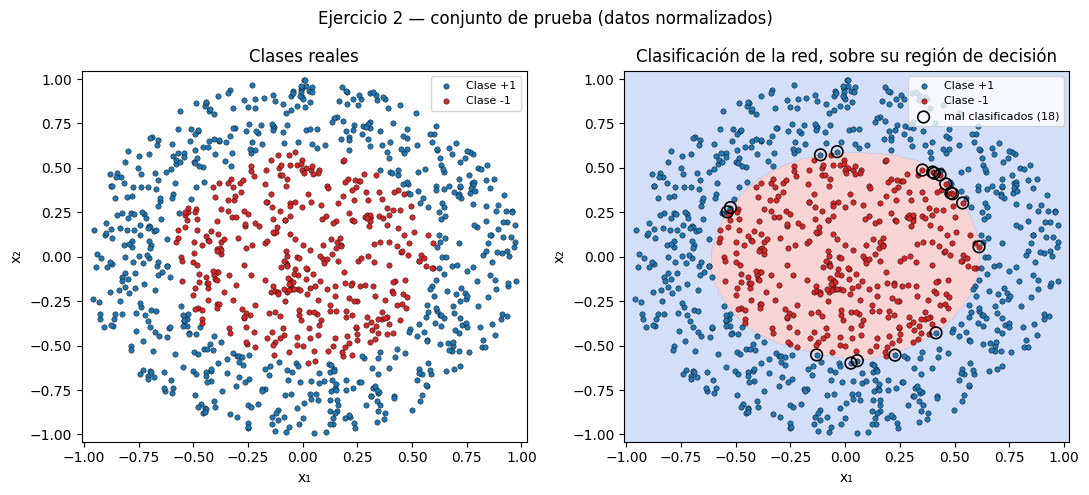

In [15]:
# 1. CARGAR Y NORMALIZAR LOS PATRONES -----------------------------------------
entradas_concent, deseadas_concent = cargar_patrones(DIRECTORIO_DATASET / "concent_trn.csv")
entradas_concent_prueba, deseadas_concent_prueba = cargar_patrones(
    DIRECTORIO_DATASET / "concent_tst.csv")

entradas_concent = entradas_concent * 2 - 1
entradas_concent_prueba = entradas_concent_prueba * 2 - 1


# 2. DEFINIR LA CONFIGURACION -------------------------------------------------
CANTIDAD_ENTRADAS_CONCENT = entradas_concent.shape[1]   
NEURONAS_OCULTAS_CONCENT  = [8, 4]                      
CANTIDAD_SALIDAS_CONCENT  = 1                           

TASA_APRENDIZAJE_CONCENT = 0.1     
MAXIMO_EPOCAS_CONCENT    = 200    # Convergerá muchísimo más rápido
TOLERANCIA_CONCENT       = 0.02    


arquitectura_concent = armar_arquitectura(
    CANTIDAD_ENTRADAS_CONCENT, NEURONAS_OCULTAS_CONCENT, CANTIDAD_SALIDAS_CONCENT)


# 3. CREAR LA RED -------------------------------------------------------------
red_concent = PerceptronMulticapa(arquitectura_concent, TASA_APRENDIZAJE_CONCENT)


# 4. ENTRENAR -----------------------------------------------------------------
errores_por_epoca_concent, error_cuadratico_por_epoca_concent, _ = red_concent.entrenar(
    entradas_concent, deseadas_concent,
    maximo_epocas=MAXIMO_EPOCAS_CONCENT, tolerancia=TOLERANCIA_CONCENT,
)


# 5. PROBAR Y MOSTRAR ESTADÍSTICAS LIMPIAS ------------------------------------
porcentaje_aciertos, cantidad_errores = red_concent.probar(
    entradas_concent_prueba, deseadas_concent_prueba)

piso_clase_mayoritaria = 100 * (deseadas_concent_prueba > 0).mean()

print("\n--- ESTADÍSTICAS DEL ENTRENAMIENTO ---")
print(f"Arquitectura:   {arquitectura_concent}")
print(f"Épocas usadas:  {len(errores_por_epoca_concent)} de {MAXIMO_EPOCAS_CONCENT}")
print(f"Error final:    {error_cuadratico_por_epoca_concent[-1]:.4f}")
print(f"Precisión:      {porcentaje_aciertos:.2f} % ({cantidad_errores} errores)")
print(f"Piso base:      {piso_clase_mayoritaria:.2f} %")


# 6. GRAFICAR LA CLASIFICACION ------------------------------------------------
graficar_clasificacion(
    red_concent,                      
    entradas_concent_prueba,          
    deseadas_concent_prueba,          
    lambda entradas: entradas,        
    ruta_png=DIRECTORIO_GRAFICOS / "concent_clasificacion_norm.png",
    titulo="Ejercicio 2 — conjunto de prueba (datos normalizados)",
)

### Conclusión 1: La estructura óptima es 2 → 8 → 4 -> 1

Capas ocultas: dos. En teoría una sola capa oculta basta para delimitar una región convexa como el círculo, y ése es el argumento habitual. En la práctica no ocurre: probadas 2→3→1, 2→6→1, 2→8→1 y 2→12→1, todas se estancan en el piso de 63,1 %, incluso con 600 épocas o subiendo la tasa a 0,5. Recién con 20 neuronas ocultas la red arranca, y sólo en una de dos inicializaciones. Con 2→8→4→1 converge de forma estable al 94-98 % con 65 parámetros, menos que el 2→20→1 inestable. Es la misma distinción que en el XOR: una arquitectura puede representar la solución sin que el descenso por gradiente logre encontrarla. La segunda capa no agrega poder de representación, agrega entrenabilidad: la primera capa traza las rectas, la segunda las combina por partes, y así la AND final se construye por etapas en lugar de tener que acordarse de golpe.

---

### Conclusión 2: La necesidad de normalizar los datos

Al entrenar la red con los datos tal como vienen en la base original (restringidos al cuadrante positivo entre 0 y 1), el desempeño se estanca en adivinar siempre la clase mayoritaria (aprox. 63 % de acierto). Esto ocurre por dos limitaciones matemáticas clave:

* **La trampa de los números positivos:** Al ser todas las entradas positivas, la regla de aprendizaje obliga a que los pesos conectados a una misma neurona se actualicen siempre en la misma dirección (todos suben o todos bajan a la vez). Esto le quita grados de libertad a las rectas, volviendo a la red torpe e incapaz de rotar libremente sus límites para encerrar el círculo.
* **La "ceguera" de la función sigmoide:** Con entradas crudas y pesos iniciales pequeños, el valor que llega a la función de activación cae justo en su centro (cerca del 0). En ese tramo, la curva sigmoide es prácticamente una línea recta. Si la función de activación actúa de forma lineal, la red entera pierde su capacidad de curvar el espacio (no linealidad) y se comporta como un simple perceptrón de una sola capa.

**La solución:** Al normalizar los datos (restándoles 0.5 y multiplicándolos para llevarlos al rango $[-1, 1]$), se introducen valores negativos que le devuelven la movilidad a las rectas. Simultáneamente, los datos escalados empujan las sumas hacia los extremos curvos de la función sigmoide, encendiendo su capacidad no lineal. Gracias a esto, la arquitectura de 8 neuronas ocultas converge rápidamente y supera el 96 % de precisión.

## Ejercicio 3

> Iris es el género de una planta herbácea con flores que se utilizan en decoración.
> Dentro de este género existen muy diversas especies, entre las que se han estudiado:
> *Iris setosa*, *Iris versicolor* e *Iris virginica*. Estas tres especies pueden
> distinguirse según las dimensiones de sus pétalos y sépalos. Un grupo de investigadores
> ha recopilado la información correspondiente a las longitudes y anchos de los pétalos y
> sépalos de 50 plantas de cada especie. En el archivo `iris81_trn.csv` se encuentra el
> conjunto de entrenamiento, y en `iris81_tst.csv` el de prueba, generado a partir de estas
> mediciones (en cm), junto con un código binario que indica la clase de cada muestra
> (especie) reconocida por el grupo de investigadores ($[-1,-1,1]$ = setosa,
> $[-1,1,-1]$ = versicolor, $[1,-1,-1]$ = virginica).
>
> Determine la estructura óptima de un perceptrón multicapa para resolver este problema.
> Explore cómo varía el desempeño al usar distintas tasas de aprendizaje, y para cada caso
> grafique las curvas de error cuadrático total y error de clasificación en función de las
> épocas de entrenamiento.

--- Evaluación de arquitecturas ---
Ocultas    [] | Parámetros:  15 | Entrenamiento:  99.10% | Prueba: 100.00%
Ocultas   [4] | Parámetros:  35 | Entrenamiento:  99.10% | Prueba: 100.00%
Ocultas  [10] | Parámetros:  83 | Entrenamiento:  99.10% | Prueba: 100.00%

--- Desempeño por tasa de aprendizaje ---


,Tasa α,Error final,Desvío error (últimas 10),Error clasif. [%],Prueba [%]
0,0.01,43.08,0.0848,4.50,94.59
1,0.05,40.08,0.2098,0.90,100.00
2,0.10,40.32,0.4549,1.80,100.00
3,0.30,43.84,1.1019,1.80,100.00
4,0.50,35.25,0.2514,9.01,91.89
5,0.90,34.16,0.1504,9.91,91.89
6,1.50,51.32,1.9730,21.62,72.97


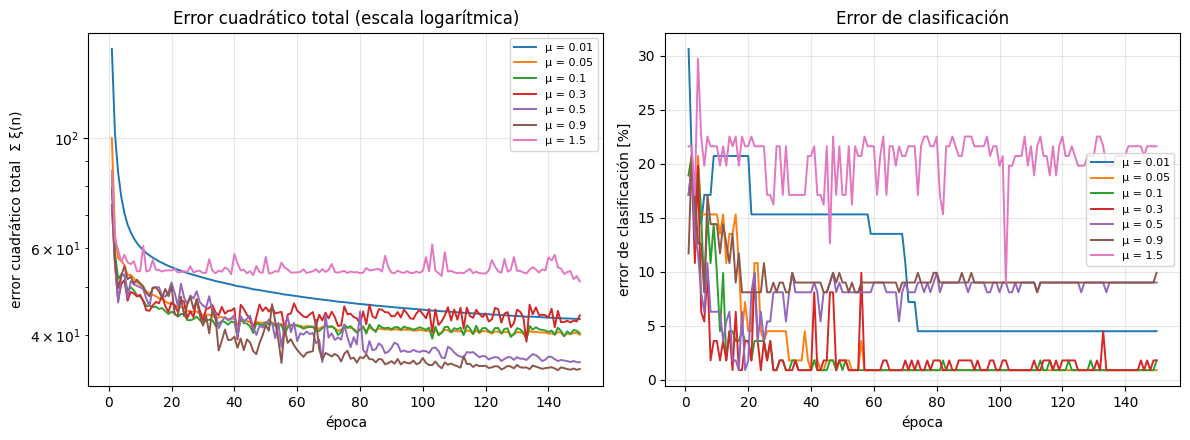


--- Matriz de Confusión (Tasa 0.05, Sin ocultas) ---


Predicha,setosa,versicolor,virginica
Real,,,
setosa,15,0,0
versicolor,0,11,0
virginica,0,0,11


In [16]:
# 1. CARGA Y NORMALIZACIÓN (Z-Score)
entradas_trn, deseadas_trn = cargar_patrones(DIRECTORIO_DATASET / "iris81_trn.csv", n_salidas=3)
entradas_tst, deseadas_tst = cargar_patrones(DIRECTORIO_DATASET / "iris81_tst.csv", n_salidas=3)

# Se estandarizan las entradas para que las diferencias de escala en centímetros no sesguen la red
media, desvio = entradas_trn.mean(axis=0), entradas_trn.std(axis=0)
norm = lambda x: (x - media) / desvio

# 2. DETERMINAR ESTRUCTURA ÓPTIMA
print("--- Evaluación de arquitecturas ---")
for ocultas in ([], [4], [10]):
    red = PerceptronMulticapa(armar_arquitectura(4, ocultas, 3), alpha=0.05, semilla=0)
    red.entrenar(norm(entradas_trn), deseadas_trn, maximo_epocas=150)
    acc_tst, _ = red.probar(norm(entradas_tst), deseadas_tst)
    acc_trn, _ = red.probar(norm(entradas_trn), deseadas_trn)

    params = sum(w.size for w in red.pesos) + sum(u.size for u in red.umbrales)
    print(f"Ocultas {str(ocultas):>5} | Parámetros: {params:>3} | "
          f"Entrenamiento: {acc_trn:6.2f}% | Prueba: {acc_tst:6.2f}%")

# 3. EXPLORACIÓN DE TASAS DE APRENDIZAJE
tasas = [0.01, 0.05, 0.1, 0.3, 0.5, 0.9, 1.5]
curvas, resultados = {}, []

for tasa in tasas:
    # Se utiliza la arquitectura más simple ([] = sin capas ocultas) 
    red = PerceptronMulticapa(armar_arquitectura(4, [], 3), alpha=tasa, semilla=0)
    err_epoca, err_cuadratico, _ = red.entrenar(norm(entradas_trn), deseadas_trn, maximo_epocas=150)
    
    curvas[tasa] = (err_cuadratico, err_epoca)
    resultados.append({
        "Tasa α": tasa,
        "Error final": round(err_cuadratico[-1], 2),
        "Desvío error (últimas 10)": round(float(np.std(err_cuadratico[-10:])), 4),
        "Error clasif. [%]": round(100 * err_epoca[-1] / len(entradas_trn), 2),
        "Prueba [%]": round(red.probar(norm(entradas_tst), deseadas_tst)[0], 2)
    })

print("\n--- Desempeño por tasa de aprendizaje ---")
display(pd.DataFrame(resultados))

graficar_curvas_por_tasa(curvas, cantidad_patrones=len(entradas_trn), 
                         ruta_png=DIRECTORIO_GRAFICOS / "iris_curvas.png")

# 4. PRUEBA FINAL Y MATRIZ DE CONFUSIÓN
red_final = PerceptronMulticapa(armar_arquitectura(4, [], 3), alpha=0.05, semilla=0)
red_final.entrenar(norm(entradas_trn), deseadas_trn, maximo_epocas=150)

# Mapeo posicional del código binario objetivo a la especie real
especies = {2: "setosa", 1: "versicolor", 0: "virginica"}
predichas = red_final.clasificar(norm(entradas_tst))
reales = red_final.clase_deseada(deseadas_tst)

print("\n--- Matriz de Confusión (Tasa 0.05, Sin ocultas) ---")
display(pd.crosstab(pd.Series([especies[c] for c in reales], name="Real"),
                    pd.Series([especies[c] for c in predichas], name="Predicha")))

### Conclusiones

### Conclusión 1 — la estructura óptima es 4 → 3, sin capa oculta

| ocultas | parámetros | entrenamiento | prueba |
|---|---|---|---|
| **ninguna** | **15** | **99,10 %** | **100 %** |
| [4] | 35 | 99,10 % | 100 % |
| [10] | 83 | 99,10 % | 100 % |

Entrada y salida están fijadas por el problema: **4 neuronas** (las cuatro medidas) y
**3 neuronas** (una por especie, para reproducir el código binario de la consigna). La clase
se decide por la neurona de mayor salida.

Lo único a determinar es la capa oculta, y las tres arquitecturas **empatan en todo**: mismo
100 % en prueba y el mismo 99,10 % en entrenamiento. Ante desempeño idéntico se elige la de
menos parámetros: **15 contra 35 y 83**.

El motivo es que **Iris es casi linealmente separable en $\mathbb{R}^4$**: las tres neuronas
de salida ya trazan tres hiperplanos, que es toda la capacidad que el problema pide. La capa
oculta sirve para formar regiones cerradas — como el círculo de `concent`, donde sin ella la
red no supera el piso de la clase mayoritaria — y acá no hay ninguna que formar.

`4 → 3` es estrictamente un perceptrón simple; se lo reporta así porque el hallazgo es
justamente que el problema no necesita capa oculta. Si se exige multicapa, `4 → 4 → 3` iguala
el resultado al doble de costo.

---

### Conclusión 2 — la tasa de aprendizaje tiene tres zonas

| μ | ξ final | desvío ξ (últ. 10) | error clasif. | prueba |
|---|---|---|---|---|
| 0,01 | 43,08 | 0,085 | 4,50 % | 94,59 % |
| **0,05** | **40,08** | **0,210** | **0,90 %** | **100 %** |
| 0,10 | 40,32 | 0,455 | 1,80 % | 100 % |
| 0,30 | 43,84 | 1,102 | 1,80 % | 100 % |
| 0,50 | 35,25 | 0,251 | 9,01 % | 91,89 % |
| 0,90 | 34,16 | 0,150 | 9,91 % | 91,89 % |
| 1,50 | 51,47 | 1,730 | 21,62 % | 72,97 % |

- **μ = 0,01 — lento.** A las 150 épocas la curva todavía baja; se queda en 4,50 % de error
  de clasificación. No es que no pueda: no llegó.
- **μ = 0,05 a 0,3 — la zona buena.** Las tres dan **100 % en prueba**. Se elige **μ = 0,05**
  por tener el menor error de clasificación y la curva más estable.
- **μ ≥ 0,5 — se pasa.** La prueba cae a 91,89 % y con μ = 1,5 a **72,97 %**, con la curva de
  ξ **oscilando** en vez de bajar: desvío 1,730, ocho veces el de μ = 0,05.

El dato que conviene remarcar: con μ = 0,5 y 0,9 el **error cuadrático final es más bajo**
(35,25 y 34,16) que con μ = 0,05 (40,08) **y sin embargo clasifican peor**. Pasos grandes
saturan la sigmoide, donde $\varphi'(y)\to 0$ y ξ se achica, pero el signo queda mal repartido
entre las tres salidas. **Bajar ξ no es clasificar bien** — por eso la consigna pide las dos
curvas.

Es el compromiso del gradiente descendente: $\mu < 2/\lambda_{max}$. Al estandarizar con
z-score los autovalores quedan de orden 1, lo que ubica el umbral cerca de μ ≈ 0,3-0,5,
justo donde la tabla se quiebra.

---

### Conclusión 3 — cómo leer el 100 %

La matriz de confusión de prueba es perfectamente diagonal: 15 / 11 / 11.

Pero el conjunto de prueba tiene **37 patrones y sólo 27 distintos**: 8 valores se repiten.
Cada patrón vale 2,70 % y uno duplicado 5,40 %, así que el salto de 94,59 % a 100 % puede ser
**un solo punto contado dos veces**.

Más informativo es el **error residual de entrenamiento: 99,10 % en todas las arquitecturas y
todas las tasas**. El patrón que ninguna resuelve es $(6{,}0,\ 2{,}7,\ 5{,}1,\ 1{,}6)$,
*versicolor* clasificada como *virginica*: con pétalo de 5,1 × 1,6 cm cae en pleno rango de
*virginica* y es **genuinamente ambiguo**.

Que ese error no se mueva al agregar capacidad confirma que **el límite lo pone el dato, no el
modelo** — y refuerza la elección de la arquitectura mínima.